<!-- 🎬 Customer Service Request Analysis¶
Author: [Avishkar Pawar]
Date: March 2026
Tools: Python | Pandas | Seaborn | Matplotlib -->

<h1>TITLE: Customer Service Request Analysis </h1>


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h1>LOAD DATASET</h1>

In [3]:
data = pd.read_csv('python_dataset.csv')

C:\Users\hp\AppData\Local\Temp\ipykernel_17276\2965512558.py:1: DtypeWarning: Columns (48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('python_dataset.csv')


<h1>EXAMINE DATASET</h1>

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364558 entries, 0 to 364557
Data columns (total 56 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Unique Key                      364558 non-null  int64         
 1   Created Date                    220593 non-null  datetime64[ns]
 2   Closed Date                     219163 non-null  datetime64[ns]
 3   Agency                          364558 non-null  object        
 4   Agency Name                     364558 non-null  object        
 5   Complaint Type                  364558 non-null  object        
 6   Descriptor                      358057 non-null  object        
 7   Location Type                   364425 non-null  object        
 8   Incident Zip                    361560 non-null  float64       
 9   Incident Address                312859 non-null  object        
 10  Street Name                     312859 non-null  object 

<h1>Columns & Shape</h1>

In [6]:
print(data.columns)
print(data.shape)

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

<h1>Null Values</h1>

In [7]:
data.isnull().sum()

Unique Key                             0
Created Date                           0
Closed Date                         2381
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6501
Location Type                        133
Incident Zip                        2998
Incident Address                   51699
Street Name                        51699
Cross Street 1                     57188
Cross Street 2                     57805
Intersection Street 1             313438
Intersection Street 2             314046
Address Type                        3252
City                                2997
Landmark                          364183
Facility Type                       2389
Status                                 0
Due Date                               3
Resolution Description                 0
Resolution Action Updated Date      2402
Community Board                        0
Borough         

<h1>Exploratory Data Analysis</h1>

#Null Values Plot

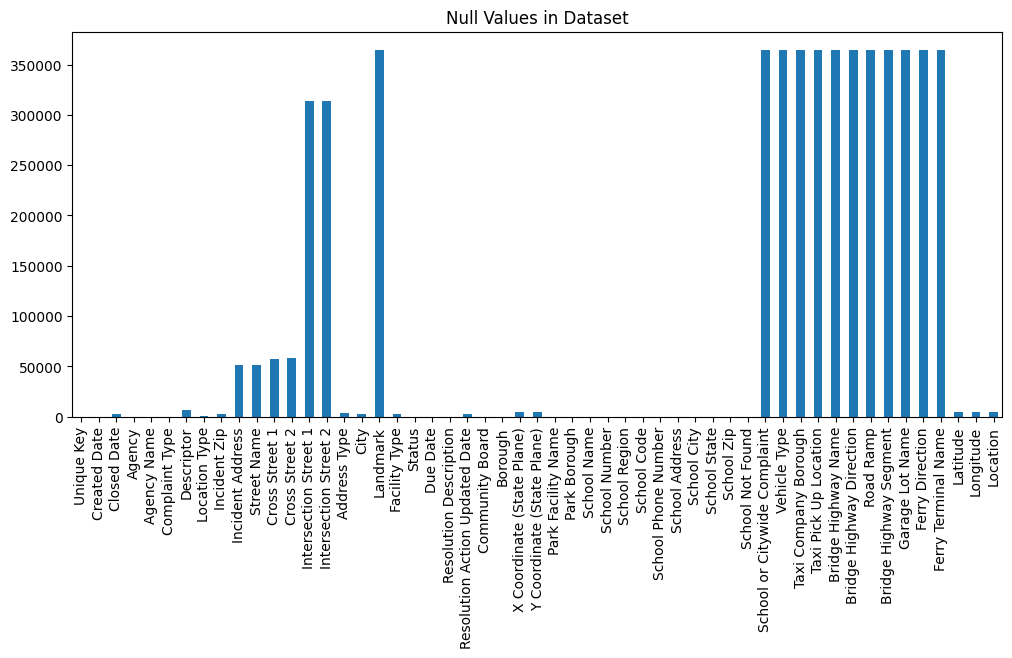

In [8]:
data.isnull().sum().plot(kind='bar', figsize=(12,5))
plt.title("Null Values in Dataset")
plt.show()

#Convert to Datetime

In [10]:
data['Created Date'] = pd.to_datetime(data['Created Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
data['Closed Date'] = pd.to_datetime(data['Closed Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
data['Due Date'] = pd.to_datetime(data['Due Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
data['Resolution Action Updated Date'] = pd.to_datetime(
    data['Resolution Action Updated Date'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

#Removing rows where closed date is null

In [12]:
data = data[data['Closed Date'].notnull()]

<h1>Data Analysis</h1>

#Remove incorrect timeline

In [14]:
data = data[data['Closed Date'] >= data['Created Date']]

#Statistics

In [19]:
data.describe()

,Unique Key,Created Date,Incident Zip,X Coordinate (State Plane),Y Coordinate (State Plane),School or Citywide Complaint,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Garage Lot Name,Latitude,Longitude
count,3.621770e+05,362177,361502.000000,3.604700e+05,360470.000000,0.0,0.0,0.0,0.0,0.0,360470.000000,360470.000000
mean,3.106545e+07,2015-07-13 19:49:29.878506240,10858.533377,1.005044e+06,203424.740428,NaN,NaN,NaN,NaN,NaN,40.724978,-73.924942
min,2.960737e+07,2015-01-01 00:00:00,83.000000,9.133570e+05,121185.000000,NaN,NaN,NaN,NaN,NaN,40.499040,-74.254937
25%,3.049763e+07,2015-04-28 08:29:08,10314.000000,9.919460e+05,182945.000000,NaN,NaN,NaN,NaN,NaN,40.668741,-73.972248
50%,3.108661e+07,2015-07-15 22:07:35,11209.000000,1.003470e+06,201023.000000,NaN,NaN,NaN,NaN,NaN,40.718398,-73.930630
75%,3.167497e+07,2015-10-04 00:12:00,11238.000000,1.019135e+06,222790.000000,NaN,NaN,NaN,NaN,NaN,40.778160,-73.874098
max,3.231065e+07,2015-12-31 23:59:45,11697.000000,1.067186e+06,271876.000000,NaN,NaN,NaN,NaN,NaN,40.912869,-73.700715
std,7.337572e+05,NaN,578.254027,2.196323e+04,29842.548376,NaN,NaN,NaN,NaN,NaN,0.081908,0.079212


#Null check

In [20]:
data[['Complaint Type', 'City']].isnull().sum()

Complaint Type      0
City              674
dtype: int64

#Fill missing city

In [21]:
data['City'].fillna("Unknown City", inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_22252\2687605250.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['City'].fillna("Unknown City", inplace=True)


<h1>KPIs</h1>

#Total Number of Requests

In [28]:
total_requests = len(data)
print("Total Requests:", total_requests)

Total Requests: 362177


#Top ComplaintsType

In [30]:
top_complaint = data['Complaint Type'].value_counts().idxmax()
print("Top Complaint Type:", top_complaint)

Top Complaint Type: Blocked Driveway


#Most Affected City

In [31]:
top_city = data['City'].value_counts().idxmax()
print("City with Most Complaints:", top_city)

City with Most Complaints: BROOKLYN


#Complaints Distribution(%)

In [32]:
complaint_dist = data['Complaint Type'].value_counts(normalize=True) * 100
print(complaint_dist.head())

Complaint Type
Blocked Driveway           27.783101
Illegal Parking            25.323530
Noise - Street/Sidewalk    14.119892
Noise - Commercial         12.080005
Derelict Vehicle            5.941294
Name: proportion, dtype: float64


<h1>#Visualization</h1>

<h1>Complaints per city</h1>

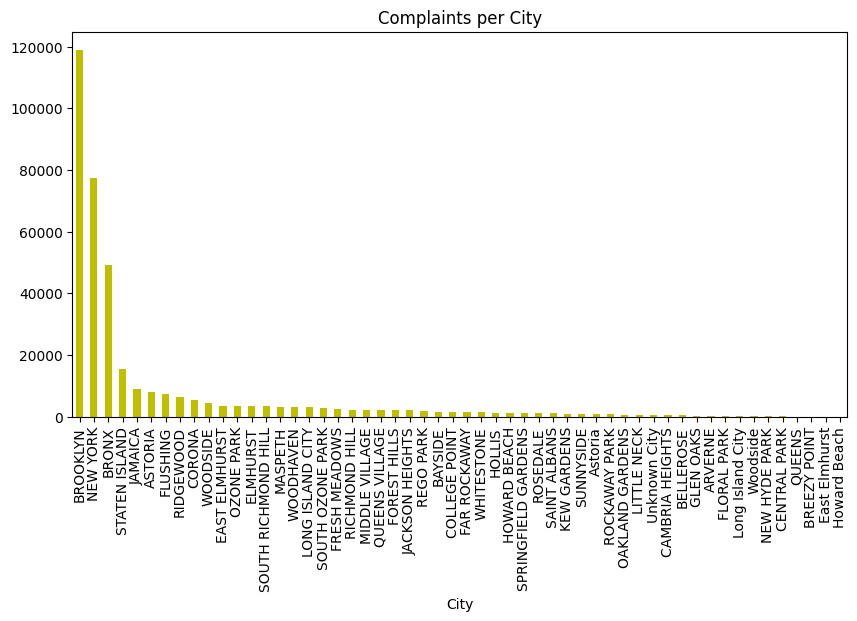

In [26]:
data['City'].value_counts().plot(kind='bar', figsize=(10,5),color='y')
plt.title("Complaints per City")
plt.show()

<h1>Complaints Types</h1>

C:\Users\hp\AppData\Local\Temp\ipykernel_22252\2919462071.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Complaint Type', order=data['Complaint Type'].value_counts().index[:10], palette='Set2')


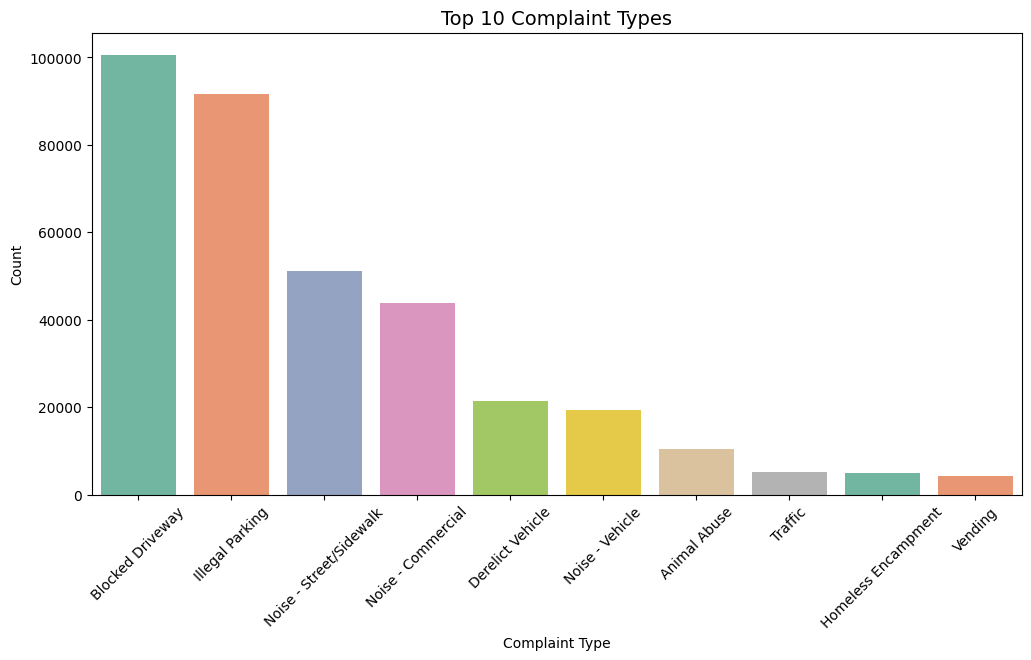

In [41]:
plt.figure(figsize=(12,6))
sns.countplot(data=data, x='Complaint Type', order=data['Complaint Type'].value_counts().index[:10], palette='Set2')

plt.title("Top 10 Complaint Types", fontsize=14)
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

Time-based Analysis

In [13]:
# feature extration
data['Year'] = data['Created Date'].dt.year
data['Month'] = data['Created Date'].dt.month
data['Hour'] = data['Created Date'].dt.hour

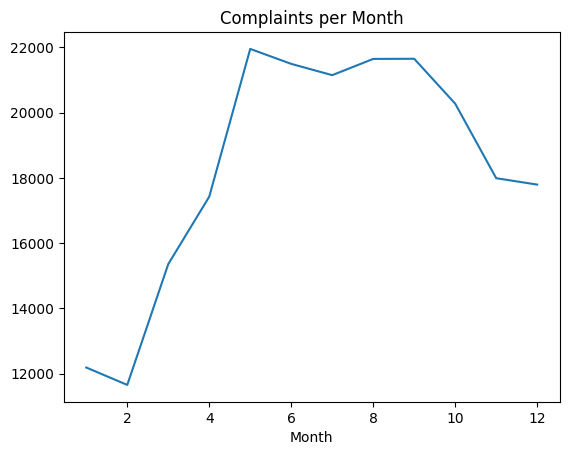

In [14]:
# monthly trend
data.groupby('Month').size().plot()
plt.title('Complaints per Month')
plt.show()

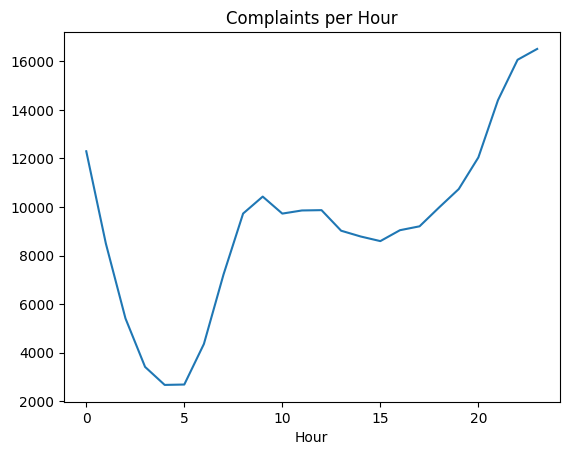

In [16]:
# hourly trend
data.groupby('Hour').size().plot()
plt.title('Complaints per Hour')
plt.show()